<a href="https://colab.research.google.com/github/kebalriv25-max/Explorando_factores_de_comportamiento_en_NovaRetail/blob/main/S8_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

El proyecto se realizo con data de la etapa de cierre del año 2024, el equipo de **Crecimiento y retención** tendra como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [76]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [77]:
# Cargar el dataset y explorar datos
df = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [78]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` no deberia ser del tipo "float" sino "int" ya que las edades son numeros enteros


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [79]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [80]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [81]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas=['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**:
Diagnóstico inicial de variables numéricas

- `edad` — la edad promedio de los clientes son adultos mayores entre 30 y 40 años
- `nivel_ingreso` — el nivel de ingreso tiene una varianza alta entre 8000 y 74790
- `visitas_mes` — el numero maximo de visitas por usuario fue de 25
- `compras_mes` — el 75% de personas compra 2 veces al mes
- `gasto_publicidad_dirigida` — existe anuncios asignados al usuario donde no se realizo ningun tipo gasto publicitario
- `satisfaccion` — el nivel de satisfaccion de los usuarios en promedio es de 3.6 el cual es un valor positivo
- `ingreso_anual` —  el promedio de ingreso anual del cliente a la empresa es de 36

#### Explorar variables binarias

In [82]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("tipos de datos: 'miembro premium': ", df['miembro_premium'].unique())
print("tipos de datos: 'abandono': ", df['abandono'].unique(),"\n")
print("proporcion de datos: 'miembro premium'",df['miembro_premium'].value_counts(),"\n")
print("proporcion de datos: 'abandono",df['abandono'].value_counts())

tipos de datos: 'miembro premium':  [0 1]
tipos de datos: 'abandono':  [0 1] 

proporcion de datos: 'miembro premium' miembro_premium
0    12911
1     2089
Name: count, dtype: int64 

proporcion de datos: 'abandono abandono
0    12739
1     2261
Name: count, dtype: int64


✍️ **Comentario**:
Diagnóstico inicial de variables binarias

- `miembro_premium` — tiene variable unicas del tipo 1 y 0 por tanto no necesita tratamiento.
- `abandono` — tiene variable unicas del tipo 1 y 0 por tanto no necesita tratamiento.

#### Explorar variables categóricas

In [83]:
# Verificar el número de valores únicos por variable categórica
print("valores unicos: tipo_dispositivo")
print(df['tipo_dispositivo'].unique())
print()
print("valores unicos: region")
print(df['region'].unique())

valores unicos: tipo_dispositivo
['móvil' 'tablet' 'escritorio']

valores unicos: region
['norte' 'sur' 'este' 'oeste']


In [84]:
# Explorar variables categóricas y cómo se distribuyen
print("valores unicos: tipo_dispositivo")
print(df['tipo_dispositivo'].value_counts(normalize=True)*100)
print()
print("valores unicos: region")
print(df['region'].value_counts(normalize=True)*100)

valores unicos: tipo_dispositivo
tipo_dispositivo
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: proportion, dtype: float64

valores unicos: region
region
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: proportion, dtype: float64


✍️ **Comentario**:
Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — el dispositivo que representa mayor incidencia es el 'movil' con 64% y el menor la 'tablet' con 9%
- `region` — la region con mayor incidencia es la region 'norte' con 29% y la menor es la region 'este' con 20%

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

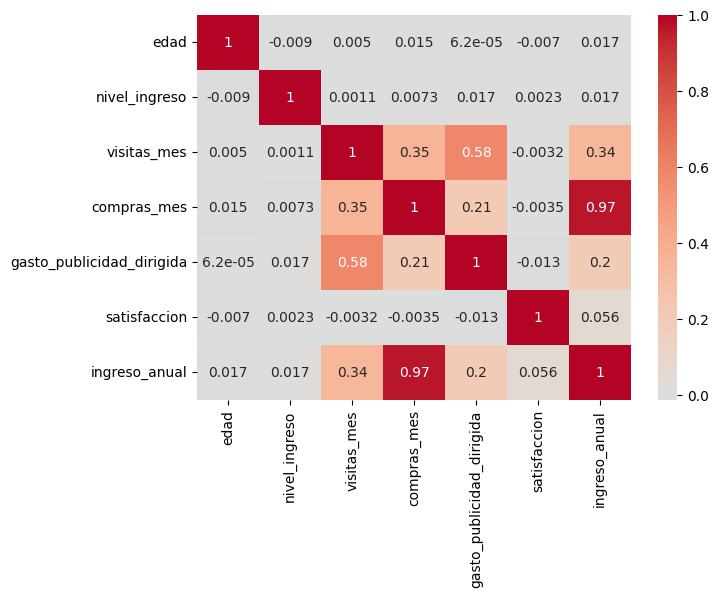

In [85]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df[columnas_numericas].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',center=0)
plt.show()


✍️ **Comentario**:

Observaciones generales (Heatmap)  
- Se observa que existe dos correlaciones fuertes entre el `ingreso_anual` y las `compras_mes` asi como el `gasto_publicidad_dirigida` y las `visitas_mes` con valores de 0.58 y 0.97 respectivamente.
- Se observa que existe dos correlaciones moderadas entre las `visitas_mes` y las columnas `ingreso_anual` asi como `compras_mes`, con los valores de 0.34 y 0.35 respectivamente


Observaciones respecto a `ingreso_anual`  
- Presenta una correlacion fuerte de valor 0.97 con las `compras_mes` muy cercana a 1 el cual debera ser revisado con detenimiento.
- Presenta una correlacion moderada de valor 0.34 con las `visitas_mes`


### Scatterplot para pares clave

Text(0.5, 1.0, 'Relacion fuerte #01')

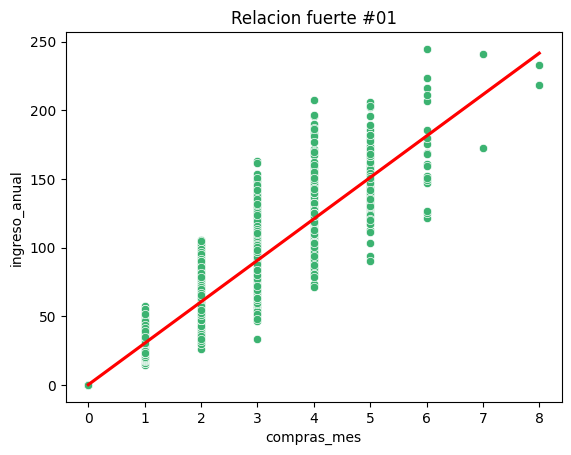

In [86]:
# Visualizar pares de variables con relaciones moderadas o fuertes
## Relaciones fuertes
sns.scatterplot(data=df[columnas_numericas],x='compras_mes',y='ingreso_anual',color='mediumseagreen')
sns.regplot(data=df[columnas_numericas],x='compras_mes',y='ingreso_anual',scatter=False,color='red')
plt.title("Relacion fuerte #01")

Text(0.5, 1.0, 'Relacion fuerte #02')

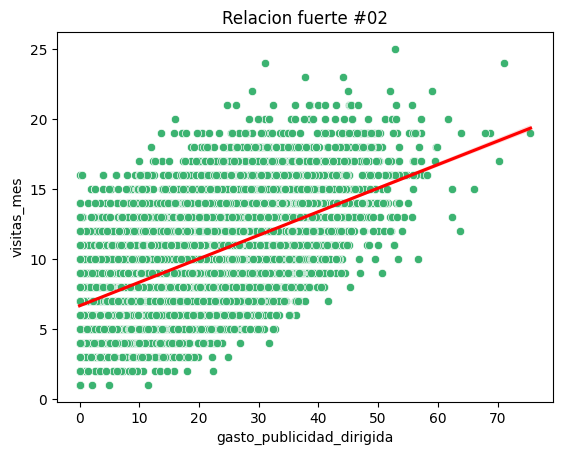

In [87]:
sns.scatterplot(data=df[columnas_numericas],x='gasto_publicidad_dirigida',y='visitas_mes',color='mediumseagreen')
sns.regplot(data=df[columnas_numericas],x='gasto_publicidad_dirigida',y='visitas_mes',scatter=False,color='red')
plt.title("Relacion fuerte #02")

Text(0.5, 1.0, 'Relacion moderada #01')

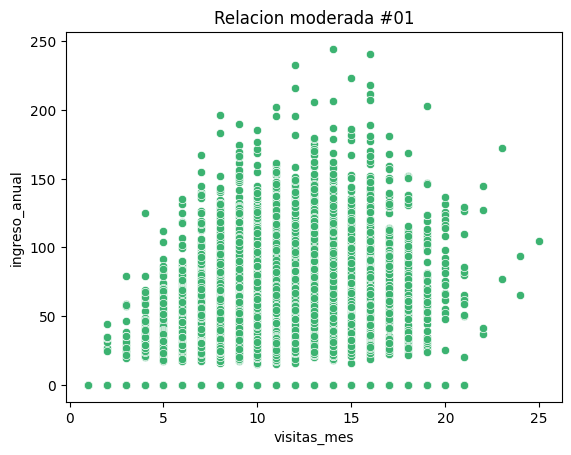

In [88]:
## Relaciones moderadas
sns.scatterplot(data=df[columnas_numericas],x='visitas_mes',y='ingreso_anual',color='mediumseagreen')
plt.title("Relacion moderada #01")

Text(0.5, 1.0, 'Relacion moderada #02')

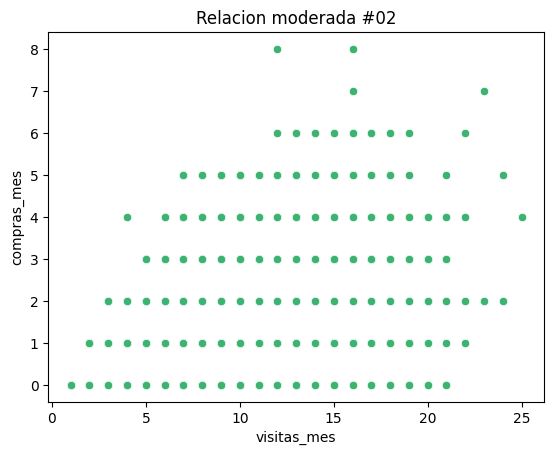

In [89]:
sns.scatterplot(data=df[columnas_numericas],x='visitas_mes',y='compras_mes',color='mediumseagreen')
plt.title("Relacion moderada #02")


✍️ **Comentario**:

Observaciones iniciales (Scatterplot)


**`ingreso_anual` vs `compras_mes`**
- Presentan una tendencia lineal con direccion positiva, no presenta dispersion ni otliers extremos observables.

**`gasto_publicidad_dirigida` vs `visitas_mes`**
- Presentan una tendencia lineal con direccion positiva, no presenta dispersion ni otliers extremos observables.

**`visitas_mes` vs `ingreso_anual`**
- Presentan una tendencia moderadamente ascendente con direccion positiva, existe una dispersion media, no se presencia outliers extremos graficamente.

**`visitas_mes` vs `compras_mes`**
- Presentan una tendencia moderadamente ascendente con direccion positiva, existe una dispersion media, no se presencia outliers extremos graficamente.



## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [90]:
# Calcular correlación entre variables relevantes
def calcular_corr(df, columnas, metodo="pearson"):
    return df[columnas].corr(method=metodo)
matriz_datos = calcular_corr(df, columnas_numericas,metodo="pearson")
matriz_datos.style.background_gradient(cmap="coolwarm").format("{:.2f}")


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.00,-0.01,0.00,0.01,0.00,-0.01,0.02
nivel_ingreso,-0.01,1.00,0.00,0.01,0.02,0.00,0.02
visitas_mes,0.00,0.00,1.00,0.35,0.58,-0.00,0.34
compras_mes,0.01,0.01,0.35,1.00,0.21,-0.00,0.97
gasto_publicidad_dirigida,0.00,0.02,0.58,0.21,1.00,-0.01,0.20
satisfaccion,-0.01,0.00,-0.00,-0.00,-0.01,1.00,0.06
ingreso_anual,0.02,0.02,0.34,0.97,0.20,0.06,1.00


In [91]:
# Calcular correlación entre variables relevantes
def calcular_corr(df, columnas, metodo="spearman"):
    return df[columnas].corr(method=metodo)
matriz_datos = calcular_corr(df, columnas_numericas,metodo="spearman")
matriz_datos.style.background_gradient(cmap="coolwarm").format("{:.2f}")


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
edad,1.00,-0.01,0.01,0.02,0.00,-0.01,0.02
nivel_ingreso,-0.01,1.00,0.00,0.01,0.02,0.01,0.03
visitas_mes,0.01,0.00,1.00,0.33,0.56,-0.00,0.32
compras_mes,0.02,0.01,0.33,1.00,0.19,-0.00,0.97
gasto_publicidad_dirigida,0.00,0.02,0.56,0.19,1.00,-0.01,0.18
satisfaccion,-0.01,0.01,-0.00,-0.00,-0.01,1.00,0.06
ingreso_anual,0.02,0.03,0.32,0.97,0.18,0.06,1.00


✍️ **Comentario**:

Observaciones de correlación

**`ingreso_anual` vs `compras_mes`**
- correlacion de spearman y pearson con valores de 0.96, existe una correlacion fuerte entre las variables pero tambien una posible colinealidad.

**`gasto_publicidad_dirigida` vs `visitas_mes`**
- correlacion de spearman y pearson con valores mayores a 0.55, existe una correlacion fuerte entre las variables.

**`visitas_mes` vs `ingreso_anual`**
- correlacion de spearman y pearson con valores mayores a 0.32, existe una correlacion moderada entre las variables.

**`visitas_mes` vs `compras_mes`**
- correlacion de spearman y pearson con valores mayores a 0.33, existe una correlacion moderada entre las variables.


### Punto-biserial

In [96]:
# Calcular correlación entre variables relevantes
columnas_binarias=['miembro_premium','abandono']
def corr_point_bis(df, col_binaria, col_numericas):
    for col in col_numericas:
        coef, p_value = pointbiserialr(df[col_binaria],df[col])

        print(f"Correlacion entre: {col_binaria} y {col}")
        print(f"PointBiserial: {coef:.4f}")

print("Miembro premium vs columnas numericas")
corr_point_bis(df, 'miembro_premium', columnas_numericas)
print()
print("Abandono vs columnas numericas")
corr_point_bis(df, 'abandono', columnas_numericas)
print()



Miembro premium vs columnas numericas
Correlacion entre: miembro_premium y edad
PointBiserial: 0.0046
Correlacion entre: miembro_premium y nivel_ingreso
PointBiserial: -0.0056
Correlacion entre: miembro_premium y visitas_mes
PointBiserial: -0.0127
Correlacion entre: miembro_premium y compras_mes
PointBiserial: 0.0034
Correlacion entre: miembro_premium y gasto_publicidad_dirigida
PointBiserial: 0.0027
Correlacion entre: miembro_premium y satisfaccion
PointBiserial: 0.0257
Correlacion entre: miembro_premium y ingreso_anual
PointBiserial: 0.0931

Abandono vs columnas numericas
Correlacion entre: abandono y edad
PointBiserial: -0.0115
Correlacion entre: abandono y nivel_ingreso
PointBiserial: 0.0059
Correlacion entre: abandono y visitas_mes
PointBiserial: -0.0089
Correlacion entre: abandono y compras_mes
PointBiserial: 0.0083
Correlacion entre: abandono y gasto_publicidad_dirigida
PointBiserial: -0.0046
Correlacion entre: abandono y satisfaccion
PointBiserial: -0.0238
Correlacion entre: ab

✍️ **Comentario**:

Observaciones Punto-biserial

- Las columnas `miembro_premium` y `abandono` ambas del tipo binaria, no presentan relacion con las columnas numericas:`edad`,`nivel_ingreso`,`visitas_mes`,`compras_mes`,`gasto_publicidad_dirigida`,`satisfaccion`.

- `miembro_premium` y `ingreso_anual` presentan una asociacion debil positiva.

### V de Cramér

In [93]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tablac = pd.crosstab(df[col1],df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tablac)
    n = tablac.values.sum()
    v= np.sqrt(chi2 / (n*(min(tablac.shape) - 1)))
    return v

In [94]:
# Aplicar V de Cramér en variables relevantes
cramer_v(df,'tipo_dispositivo','region')


np.float64(0.012378338407739397)

✍️ **Comentario**:

Observaciones V de Cramér: De acuerdo al valor obtenido de 0.01 no existe relacion entre las dos unicas variables categoricas `tipo_dispositivo` y `region`


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 —

**Evidencia visual:**
Heatmap de correlaciones (Sección 3) — celda de color rojo intenso entre `ingreso_anual` y `compras_mes`.

**Evidencia numérica:**
Pearson = 0.97 · Spearman = 0.96 (ambos métodos confirman la misma dirección y magnitud)

**Interpretación**  
Existe una asociación positiva muy fuerte entre la frecuencia de compras mensuales y el ingreso anual generado por el cliente. A medida que aumenta el número de compras por mes, el ingreso anual tiende a crecer de manera casi proporcional. La coincidencia entre Pearson y Spearman sugiere que la relación es tanto lineal como monótona, lo cual la hace robusta. Sin embargo, la magnitud (cercana a 1.0) es inusualmente alta y merece verificación: podría indicar colinealidad estructural o que ambas variables derivan de una misma fuente de datos.

**No podemos afirmar**  
Que incrementar artificialmente las compras (por ejemplo, mediante descuentos) causará un aumento equivalente en el ingreso anual. La correlación no establece dirección causal, y parte de la asociación podría explicarse porque `ingreso_anual` se calcula directamente a partir de `compras_mes`.

**Implicación de negocio**  
Se recomienda revisar la definición de ambas variables antes de usarlas en un modelo predictivo. Si son independientes, `compras_mes` sería el mejor candidato para segmentar clientes de alto valor. Una hipótesis a explorar: los clientes que compran 3 o más veces al mes podrían representar un segmento desproporcionadamente rentable que justifique programas de fidelización específicos.

### Hallazgo 2 —

**Evidencia visual:**
Heatmap de correlaciones del paso 3 - Relación positiva entre el `gasto_publicidad_dirigida` y `visitas_mes`

**Evidencia numérica:**
Correlación de Spearman y Pearson con valores > 0.55 entre `gasto_publicidad_dirigida` y `visitas_mes`

**Interpretación**  
Se observa que a medida que aumenta la inversión en publicidad dirigida hacia un cliente, también tiende a ser mayor la cantidad de visitas que este realiza a la plataforma durante el mes.

**No podemos afirmar**  
No podemos asegurar de manera definitiva que la publicidad es la causa directa del aumento en las visitas. Existe la hipótesis de que el algoritmo de marketing simplemente esté asignando más presupuesto publicitario a usuarios que, por sus características, ya eran naturalmente más propensos a navegar por la tienda.

**Implicación de negocio**  
El equipo de Crecimiento y Retención podría implementar pruebas controladas para medir el verdadero retorno de inversión. Esto importaría para dejar de gastar presupuesto en usuarios que visitarían la plataforma orgánicamente y redistribuirlo para reactivar a aquellos con baja frecuencia de visitas.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad: Ninguna de las asociaciones identificadas en este análisis permite afirmar que una variable produce un cambio en otra. Los coeficientes describen patrones, no mecanismos.
- Posibles variables no medidas: El dataset no incluye variables como ticket promedio por compra, categorías de productos adquiridos, tiempo de permanencia en sesión, historial de devoluciones o uso de cupones, todas ellas potencialmente asociadas al ingreso anual.
- Sugerencias de segmentación: Factores como estacionalidad, campañas promocionales activas o condiciones económicas regionales no están representados, lo que limita la capacidad de interpretar variaciones en el ingreso anual.
- Ideas para análisis o experimentos futuros: El dataset incluye clientes con compras_mes = 0 e ingreso_anual = 0. Estudiar su perfil (edad, región, dispositivo, satisfacción) podría revelar patrones de clientes en riesgo de abandono antes de que ocurra.   

### **Próximos pasos**

Probar segmentación adicional
- Verificar la relación entre compras_mes e ingreso_anual. Confirmar con el equipo de datos si `ingreso_anual` se calcula directamente a partir de `compras_mes`. Si es así, excluir una de las dos variables de futuros modelos para evitar colinealidad.
- Crear grupos de clientes (ej. 0, 1–2, 3–5, 6+ compras/mes) y comparar su ingreso anual promedio. Para asi plantear una hipótesis como: los clientes con 3 o más compras mensuales concentran una proporción desproporcionada del ingreso total.
- Identificar clientes con alta frecuencia de visita pero baja compra (visitantes no convertidos) como segmento prioritario para intervención de marketing.


Incorporar variables no medidas en una próxima recolección de datos
- Ticket promedio, categoría de producto, tiempo por sesión y frecuencia de devoluciones enriquecerían el análisis y podrían revelar asociaciones hoy invisibles.

Diseñar un experimento sobre publicidad dirigida
- Dado que `gasto_publicidad_dirigida` y `visitas_mes` están fuertemente correlacionados, un test A/B controlando el presupuesto publicitario permitiría estimar si el gasto en publicidad efectivamente incrementa visitas y, en segunda instancia, compras e ingreso.